In [ ]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

import pandas as pd

In [ ]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 1e-4
    weight_decay = 1e-4
    train_split = 0.8
    device = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()

In [ ]:
print(torch.__version__)
print(torch.version.cuda)

2.11.0+cu128
12.8


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # Bottleneck
        b = self.bottleneck(p4)

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform

        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, mask = self.dataset[idx]
        mask = np.array(mask)

        # foreground = 1, background = 0
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (
            2. * intersection + self.smooth
        ) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

In [ ]:
class Trainer:
    def __init__(self, config):

        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

        self.model = UNet().to(config.device)

        self.criterion = BCEDiceLoss()

        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='max',
            factor=0.5,
            patience=2
        )

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_iou': [],
            'val_f1': []
        }

        self.setup_dataloader()

    def setup_dataloader(self):

        dataset = PetDataset(
            root="./data",
            split='trainval',
            transform=self.transform
        )

        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(
            dataset,
            [train_size, val_size]
        )

        self.test_dataset = PetDataset(
            root="./data",
            split='test',
            transform=self.transform
        )

        self.train_dataloader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True
        )

        self.val_dataloader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )

        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )

    def run(self):

        for epoch in range(self.config.epochs):

            train_loss = self.train()

            val_loss, val_iou, val_f1 = self.validate()

            self.scheduler.step(val_iou)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(
                f"Epoch {epoch+1} / {self.config.epochs}, "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val IoU: {val_iou:.4f}, "
                f"Val F1-score: {val_f1:.4f}"
            )

        print('Testing...')

        test_loss, test_iou, test_f1 = self.test()

        print(
            f"Test Loss: {test_loss:.4f}, "
            f"Test IoU: {test_iou:.4f}, "
            f"Test F1-score: {test_f1:.4f}"
        )

    def train(self):

        self.model.train()

        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):

            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)

            loss = self.criterion(outputs, masks)

            loss.backward()

            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):

        self.model.eval()

        val_loss = 0

        iou_scores = []
        f1_scores_list = []

        with torch.no_grad():

            for images, masks in tqdm(self.val_dataloader):

                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)

                loss = self.criterion(outputs, masks)

                val_loss += loss.item()

                pred_masks = (
                    torch.sigmoid(outputs).cpu().numpy() > 0.5
                ).astype(np.uint8)

                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):

                    iou_scores.append(
                        jaccard_score(
                            masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average='binary'
                        )
                    )

                    f1_scores_list.append(
                        f1_score(
                            masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average='binary'
                        )
                    )

        return (
            val_loss / len(self.val_dataloader),
            np.mean(iou_scores),
            np.mean(f1_scores_list)
        )

    def test(self):

        self.model.eval()

        test_loss = 0

        iou_scores = []
        f1_scores_list = []

        with torch.no_grad():

            for images, masks in tqdm(self.test_dataloader):

                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)

                loss = self.criterion(outputs, masks)

                test_loss += loss.item()

                pred_masks = (
                    torch.sigmoid(outputs).cpu().numpy() > 0.5
                ).astype(np.uint8)

                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):

                    iou_scores.append(
                        jaccard_score(
                            masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average='binary'
                        )
                    )

                    f1_scores_list.append(
                        f1_score(
                            masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average='binary'
                        )
                    )

        return (
            test_loss / len(self.test_dataloader),
            np.mean(iou_scores),
            np.mean(f1_scores_list)
        )

    def inference_and_plot_samples(self, n_samples=3):

        self.model.eval()

        with torch.no_grad():

            fig, axes = plt.subplots(
                n_samples,
                3,
                figsize=(10, 3 * n_samples)
            )

            for i in range(n_samples):

                img, mask = self.test_dataset[i]

                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)

                output = torch.sigmoid(output).squeeze().cpu().numpy()

                output = (output >= 0.5).astype(float)

                axes[i, 0].imshow(
                    img.permute(1, 2, 0).cpu()
                )

                axes[i, 0].set_title("Image")

                axes[i, 1].imshow(
                    mask.squeeze().cpu(),
                    cmap="gray"
                )

                axes[i, 1].set_title("Ground Truth")

                axes[i, 2].imshow(
                    output,
                    cmap="gray"
                )

                axes[i, 2].set_title("Predicted Mask")

            plt.tight_layout()
            plt.show()

In [ ]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:45<00:00, 17.2MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 6.64MB/s]


In [ ]:
trainer.run()

100%|██████████| 23/23 [00:12<00:00,  1.83it/s]


Epoch 1 / 15, Train Loss: 0.8111, Val Loss: 0.6597, Val IoU: 0.7796, Val F1-score: 0.8699


100%|██████████| 23/23 [00:12<00:00,  1.89it/s]


Epoch 2 / 15, Train Loss: 0.5856, Val Loss: 0.5415, Val IoU: 0.8197, Val F1-score: 0.8951


100%|██████████| 23/23 [00:12<00:00,  1.90it/s]


...

Epoch 14 / 15, Train Loss: 0.2476, Val Loss: 0.2882, Val IoU: 0.8836, Val F1-score: 0.9337


100%|██████████| 23/23 [00:12<00:00,  1.89it/s]


Epoch 15 / 15, Train Loss: 0.2337, Val Loss: 0.2881, Val IoU: 0.8815, Val F1-score: 0.9330
Testing...


100%|██████████| 115/115 [01:01<00:00,  1.86it/s]

Test Loss: 0.2888, Test IoU: 0.8802, Test F1-score: 0.9322


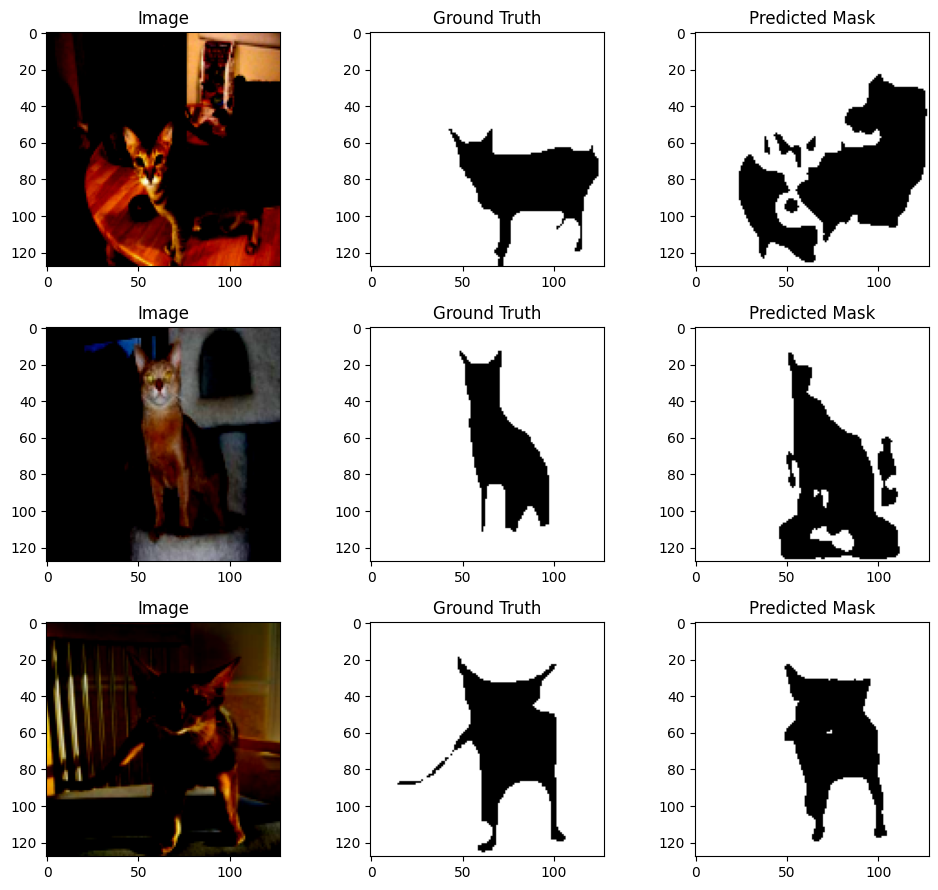

In [ ]:
trainer.inference_and_plot_samples(n_samples=3)

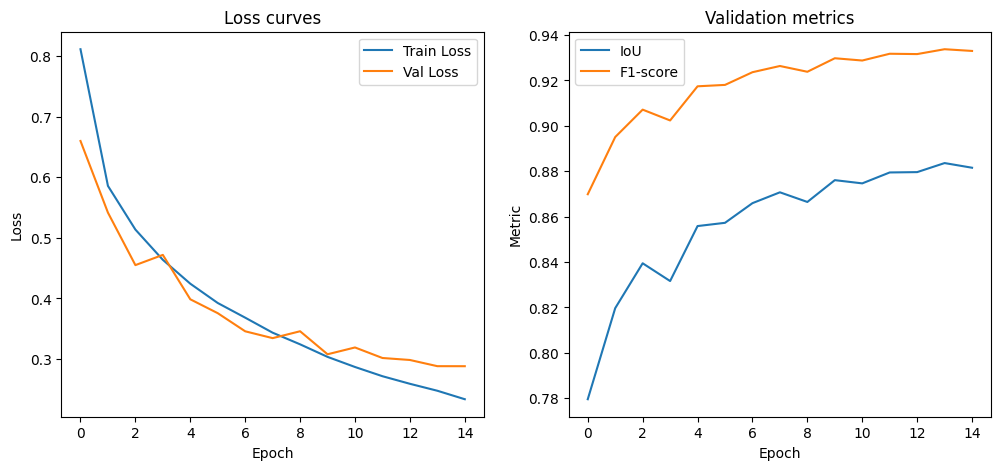

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trainer.history['train_loss'], label='Train Loss')
plt.plot(trainer.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(trainer.history['val_iou'], label='IoU')
plt.plot(trainer.history['val_f1'], label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.legend()
plt.title('Validation metrics')

plt.show()

In [ ]:
results = []

learning_rates = [1e-3, 1e-4, 1e-5]
batch_sizes = [16, 32, 64]

for lr in learning_rates:
    for bs in batch_sizes:
        print(f'Experiment: lr={lr}, batch_size={bs}')

        config.learning_rate = lr
        config.batch_size = bs
        config.epochs = 5

        trainer = Trainer(config)
        trainer.run()

        _, test_iou, test_f1 = trainer.test()

        results.append({
            'lr': lr,
            'batch_size': bs,
            'IoU': test_iou,
            'F1': test_f1
        })

Experiment: lr=0.001, batch_size=16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.59it/s]


Epoch 1 / 5, Train Loss: 0.7080, Val Loss: 0.6189, Val IoU: 0.7429, Val F1-score: 0.8456


100%|██████████| 46/46 [00:12<00:00,  3.65it/s]


Epoch 2 / 5, Train Loss: 0.5828, Val Loss: 0.6074, Val IoU: 0.7684, Val F1-score: 0.8606


...

100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 5 / 5, Train Loss: 0.6617, Val Loss: 0.6051, Val IoU: 0.7986, Val F1-score: 0.8832
Testing...


100%|██████████| 58/58 [01:04<00:00,  1.11s/it]


Test Loss: 0.6027, Test IoU: 0.7964, Test F1-score: 0.8801


100%|██████████| 58/58 [01:04<00:00,  1.11s/it]


In [ ]:
results_df = pd.DataFrame(results)
results_df

,lr,batch_size,IoU,F1
0,0.00100,16,0.803649,0.883322
1,0.00100,32,0.833324,0.902429
2,0.00100,64,0.827252,0.899440
3,0.00010,16,0.857949,0.918634
4,0.00010,32,0.847748,0.912155
5,0.00010,64,0.796284,0.878690
6,0.00001,16,0.786301,0.873551
7,0.00001,32,0.806961,0.887053
8,0.00001,64,0.796430,0.880131


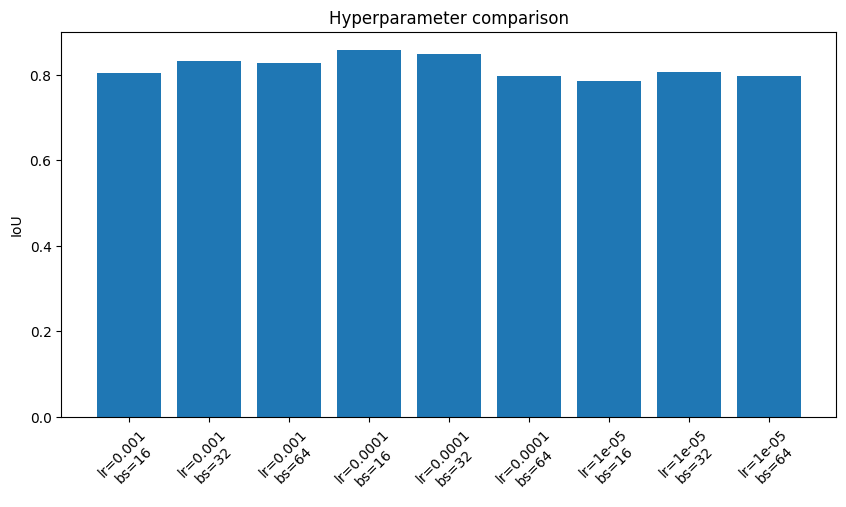

In [ ]:
plt.figure(figsize=(10, 5))

labels = [f"lr={r['lr']}\nbs={r['batch_size']}" for r in results]
ious = [r['IoU'] for r in results]

plt.bar(labels, ious)
plt.ylabel('IoU')
plt.title('Hyperparameter comparison')
plt.xticks(rotation=45)

plt.show()